In [21]:
import yaml
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
idx = pd.IndexSlice

In [7]:
with open(Path.cwd().parent / 'data' / 'interconnection_helpers.yaml', 'r') as f:
    interconnector_helpers = yaml.safe_load(f)

In [12]:
cs = interconnector_helpers['interconnection_countries']

In [ ]:
path = Path.cwd() / 'clusterdata'

In [4]:
inter = pd.read_csv(
    path / 'gathered_interconnector_flows.csv', index_col=0, parse_dates=True, header=[0,1]
)

In [20]:
mp = pd.read_csv(
    path / 'gathered_marginal_prices.csv', index_col=0, parse_dates=True, header=[0,1]
)

In [125]:
imports = inter.clip(lower=0)
exports = inter.clip(upper=0)
national_operation = inter.loc[:, idx['national', :]]
nodal_operation = inter.loc[:, idx['nodal', :]]

national_operation.columns = national_operation.columns.droplevel(0)
nodal_operation.columns = nodal_operation.columns.droplevel(0)

In [126]:
# national_operation = national_operation.T.groupby(lambda x: 'France' if x in ['IFA1', 'IFA2', 'ElecLink'] else x).sum().T
# nodal_operation = nodal_operation.T.groupby(lambda x: 'France' if x in ['IFA1', 'IFA2', 'ElecLink'] else x).sum().T

In [127]:
ics = inter.columns.get_level_values(1).unique()

national_profits = pd.DataFrame(index=imports.index, columns=ics)
rnp_profits = pd.DataFrame(index=imports.index, columns=ics)

for ic in tqdm(ics):

    price_diff_national = mp.loc[:, idx['national', 'GB']] - mp.loc[:, idx['national', country]]
    price_diff_rnp = mp.loc[:, idx['rnp1', 'GB']] - mp.loc[:, idx['rnp1', country]]

    national_profits[ic] = national_operation.loc[:, ic] * price_diff_national * 0.5e-3
    rnp_profits[ic] = nodal_operation.loc[:, ic] * price_diff_rnp * 0.5e-3

100%|██████████| 7/7 [00:00<00:00, 438.28it/s]


In [130]:
national_profits.sum()

Link
BritNed      42679.333898
IFA1         84568.040429
IFA2         74018.862421
Nemo         49124.593737
ElecLink     46887.563941
NSL          91708.398148
Viking      107455.254430
dtype: float64

In [131]:
rnp_profits.sum()

Link
BritNed       8448.311419
IFA1        103246.867088
IFA2         80887.398257
Nemo         29118.076010
ElecLink     53425.909676
NSL         117371.887018
Viking       45608.013404
dtype: float64

In [132]:
national_profits.sum().sum() - rnp_profits.sum().sum()

58335.58413462277

In [113]:
start, end = '2024-04-01', '2024-04-03'

<AxesSubplot:xlabel='snapshot'>

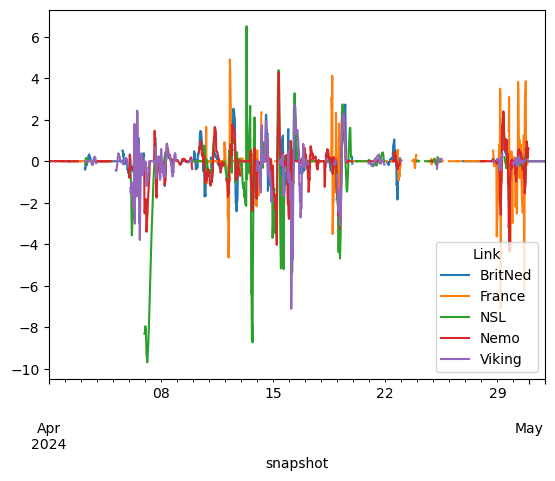

In [112]:
change_cost.loc[start:end].plot()

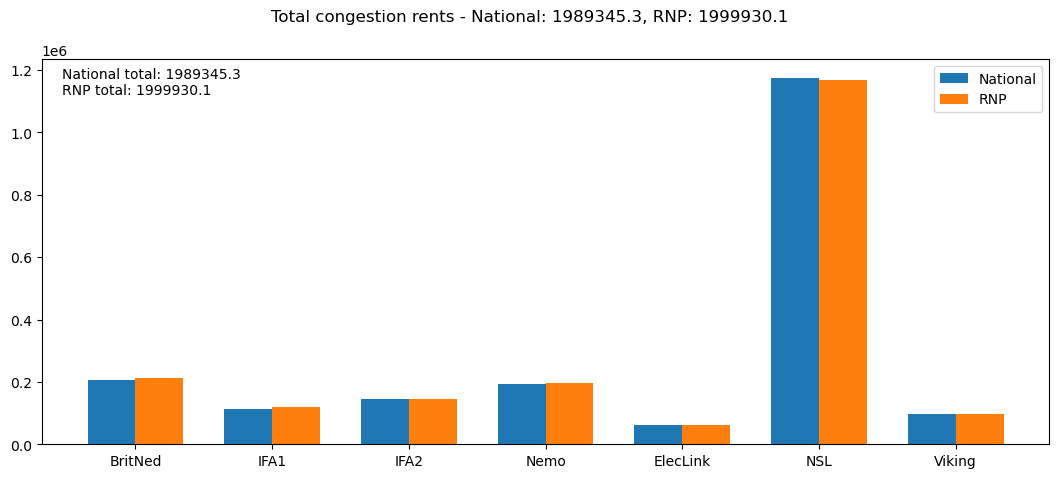

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

# Combine imports and exports into single congestion rent values
nat_cr = nat_imp_cr.sum() + nat_exp_cr.sum()
rnp_cr = rnp_imp_cr.sum() + rnp_exp_cr.sum()

# Create grouped bar plot
x = np.arange(len(nat_cr))
width = 0.35

ax.bar(x - width/2, nat_cr, width, label='National')
ax.bar(x + width/2, rnp_cr, width, label='RNP')
ax.set_xticks(x)
ax.set_xticklabels(nat_cr.index)
ax.legend()

# Add total sums to upper left corner
ax.text(0.02, 0.98,
        f'National total: {nat_cr.sum():.1f}\nRNP total: {rnp_cr.sum():.1f}',
        transform=ax.transAxes,
        verticalalignment='top')

plt.suptitle(f'Total congestion rents - National: {nat_cr.sum():.1f}, RNP: {rnp_cr.sum():.1f}')

plt.show()

In [71]:
ics

Index(['BritNed', 'IFA1', 'IFA2', 'Nemo', 'ElecLink', 'NSL', 'BritNed', 'IFA1',
       'IFA2', 'Nemo', 'ElecLink', 'NSL', 'Viking', 'Viking'],
      dtype='object', name='Link')